In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import lightning as L
from pytorch_lightning.loggers import WandbLogger
from pytorch_optimizer import Lion
from lightning_module import LOfTransformer
from utils.data_utils import *
from of_dataset import OfDataset
from torch.utils.data import random_split


import copy
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

In [4]:
# Load pseudodata file
f_pd = uproot.open("Pseudodata_WithSherapaNoReweighting_12May2025.root")
t_pd = f_pd["OmniTree"]

# Load pass 190 and isTop flags
pass190_pd = ak.to_numpy(t_pd["pass190"].array())
is_top = ak.to_numpy(t_pd["isTop"].array())
filtered_is_top = is_top[pass190_pd == 1]

# Load PD kinematics, dropping top evets
print(f"pd events: {np.sum(pass190_pd)}")
print("We have a fraction {} of good events in pseudodata".format(np.sum(pass190_pd) / len(pass190_pd)))
print(f"Of these good events, {np.sum(filtered_is_top)} are top")
pd_kinematics, pd_ind = get_kinematics(t_pd, muon_only=False)
pd_kinematics = pd_kinematics[filtered_is_top == 0]
pd_ind = pd_ind[filtered_is_top == 0]

pd events: 233729
We have a fraction 1.0 of good events in pseudodata
Of these good events, 617 are top


In [5]:
# Load top MC files
f_top = uproot.open("ZjetOmnifold_14May2025_Background_Sherpa2212_AllTop_WithTracks_slim_Systematics.root")
t_top = f_top["OmniTree"]
# Load Top kinematics
pass190_top = ak.to_numpy(t_top['pass190'].array())
print(f"top events: {np.sum(pass190_top)}")
print("We have a fracion {} of good events in top".format(np.sum(pass190_top) / len(pass190_top)))
top_kinematics, top_ind = get_kinematics(t_top, muon_only=False)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.
top events: 21017
We have a fracion 0.9988593698018156 of good events in top


In [6]:
pd_obs = np.stack(get_observables(t_pd, ["pT_ll", "y_ll", "y_trackj1", "y_trackj2"]), axis=0)
pd_obs = pd_obs[filtered_is_top == 0, :]
top_obs = np.stack(get_observables(t_top, ["pT_ll", "y_ll", "y_trackj1", "y_trackj2"]), axis=0)

In [7]:
# Build labels: top is 1 and pd is 0
top_labels = np.ones((len(top_kinematics), 1), dtype=np.float32)
pd_labels = np.zeros((len(pd_kinematics), 1), dtype=np.float32)

In [8]:
# Calculate weights
nf_top = 2 * len(top_kinematics) / (len(top_kinematics) + len(pd_kinematics))
nf_pd = 2 * len(pd_kinematics) / (len(top_kinematics) + len(pd_kinematics))

weight_top = np.ones((len(top_kinematics), 1)) / nf_top
weight_pd = np.ones((len(pd_kinematics), 1)) / nf_pd

In [9]:
print("Number of PD events: ", len(pd_kinematics))
print("Number of top events: ", len(top_kinematics))
print("Sum of top weights: ", np.sum(weight_top))
print("Sum of pd weights: ", np.sum(weight_pd))
print("Sum of all weights: ", np.sum(weight_top) + np.sum(weight_pd))

Number of PD events:  233112
Number of top events:  21017
Sum of top weights:  127064.5
Sum of pd weights:  127064.50000000009
Sum of all weights:  254129.0000000001


In [10]:
# Create data sets
top_dataset = OfDataset(
    kinematics=top_kinematics,
    labels=top_labels,
    weights=weight_top,
    object_indeces=top_ind,
    w1_obs=top_obs,
    n_jets=5,
    max_tracks=264,
)

pd_dataset = OfDataset(
    kinematics=pd_kinematics,
    labels=pd_labels,
    weights=weight_pd,
    object_indeces=pd_ind,
    w1_obs=pd_obs,
    n_jets=5,
    max_tracks=264,
)

all_dataset = copy.deepcopy(top_dataset)
all_dataset.concatenate(pd_dataset)

In [11]:
# Get total dataset size
total_size = len(all_dataset)

# Calculate split sizes (80% train, 20% test)
test_size = int(0.2 * total_size)
train_size = total_size - test_size

print(f"Total dataset size: {total_size}")
print(f"Training size: {train_size}")
print(f"Testing size: {test_size}")

# Split the dataset
train_dataset, test_dataset = random_split(
    all_dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducible splits
)

print(f"Train dataset length: {len(train_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=256,  
    shuffle=True,
    num_workers=0,
    collate_fn=null_collate,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=256,
    shuffle=False,  #  don't shuffle test data
    num_workers=0,
    collate_fn=null_collate,
)

Total dataset size: 254129
Training size: 203304
Testing size: 50825
Train dataset length: 203304
Test dataset length: 50825


In [12]:
# Initialize the model and trainer
block_params = {
    "dropout": 0.02,
    "attn_dropout": 0.02,
    "activation_dropout": 0.0,
}
cls_block_params = {
    "dropout": 0.0,
    "attn_dropout": 0.0,
    "activation_dropout": 0.0,
}

model = LOfTransformer(
    input_dim=10,
    seed=42,
    pair_input_dim=4,  # Refers to the number of pairwise features to use
    global_input_dim=4,  # The four features loaded above
    global_embed_dims=[64],  # Global features embedding MLP, layer to produce hidden dim added automatically
    embed_dims=[128, 512, 128],
    pair_embed_dims=[64, 64, 64],
    fc_nodes=[128, 64],  # Classifier head
    num_classes=1,
    num_heads=8,
    num_layers=6,
    num_cls_layers=2,
    block_params=block_params,
    cls_block_params=cls_block_params,
    fc_dropout=0.0,
    activation="gelu",
    remove_self_pair=False,
    max_lr=1e-5,
    min_lr=1e-6,
)

In [14]:
trainer.fit(model, train_loader, test_loader)

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:639: Checkpoint directory /global/cfs/cdirs/m3246/twamorka/zjets_omnifold/checkpoints/top-classifier/test-001 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type              | Params
------------------------------------------------
0 | criterion | BCEWithLogitsLoss | 0     
1 | model     | OfTransformer     | 1.8 M 
2 | val_auc   | BinaryAUROC       | 0     
3 | test_auc  | BinaryAUROC       | 0     
------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.096     Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [13]:
store_location = "./checkpoints/top-classifier/test-001"

# logger = WandbLogger(
#     project="top-subtraction",
#     name="top-classifier-test",
#     save_dir=store_location,
# )

lr_monitor = L.pytorch.callbacks.LearningRateMonitor(logging_interval="step")

checkpoints = L.pytorch.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filename="{epoch:02d}-{step:06d}-{val_loss:.1f}",
    save_top_k=1,
    mode="min",
    dirpath=store_location,
)

early_stopping = L.pytorch.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
)

trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    logger=None,
    callbacks=[lr_monitor, checkpoints, early_stopping],
    default_root_dir=store_location,
    max_epochs=10,
    enable_progress_bar=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [15]:
model = LOfTransformer.load_from_checkpoint(
    "/global/homes/k/kgreif/zjets/work_dirs/zjets_omnifold1/checkpoints/top-classifier/test-001/epoch=09-step=007950-val_loss=0.3.ckpt",
    input_dim=10,
    seed=42,
    pair_input_dim=4,  # Refers to the number of pairwise features to use
    global_input_dim=4,  # The four features loaded above
    global_embed_dims=[
        64
    ],  # Global features embedding MLP, layer to produce hidden dim added automatically
    embed_dims=[128, 512, 128],
    pair_embed_dims=[64, 64, 64],
    fc_nodes=[128, 64],  # Classifier head
    num_classes=1,
    num_heads=8,
    num_layers=6,
    num_cls_layers=2,
    block_params=block_params,
    cls_block_params=cls_block_params,
    fc_dropout=0.0,
    activation="gelu",
    remove_self_pair=False,
    max_lr=1e-5,
    min_lr=1e-6,
)

In [21]:
preds_test = trainer.predict(model, test_loader)
preds_test = torch.cat([pred.cpu().flatten() for pred in preds_test])

/global/common/software/m3246/conda/zfjets/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /global/common/software/m3246/conda/zfjets/lib/pytho ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/global/common/software/m3246/conda/zfjets/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [37]:
probs_test = preds_test.numpy()
probs_test = 1 / (1 + np.exp(-probs_test))

In [ ]:
test_labels = test_dataset[:][1].cpu().numpy().flatten()

(50825,)
[0. 0. 0. 0. 1. 1. 0. 1. 0. 0.]


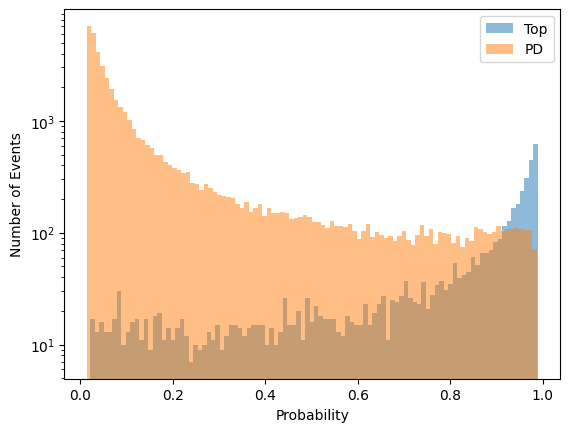

In [40]:
plt.hist(probs_test[test_labels == 1], bins=100, alpha=0.5, label="Top")
plt.hist(probs_test[test_labels == 0], bins=100, alpha=0.5, label="PD")
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Number of Events")
plt.legend()
plt.show()